#### 1. Импорт библиотек

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### 2. Загрузка данных

In [15]:
df = pd.read_csv('/Users/timurdorziev/online_retail_analysis/data/O_Retail.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


#### 3. Первичный анализ
   

In [19]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

#### 4. Очистка данных

In [27]:
# Удалим пропуски
df = df.dropna()

# Удалим отмененные заказы (если InvoiceNo начинается с "С")
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Удалим отрицательные значения
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

#### 5. Создание новых признаков 

In [31]:
# Общая сумма покупки
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

#### 6. Анализ по странам 

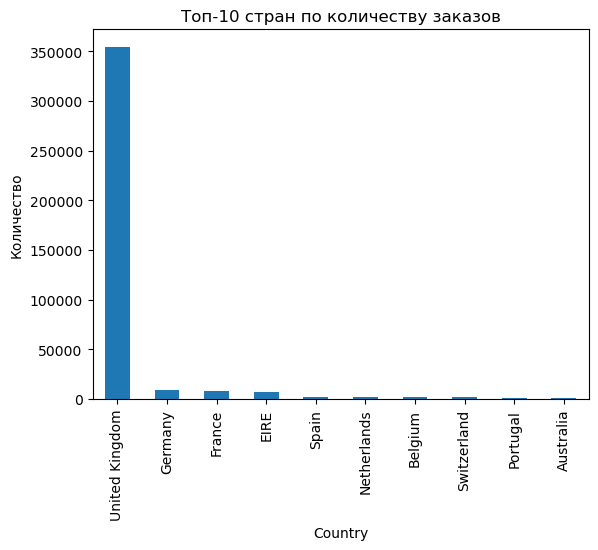

In [35]:
df['Country'].value_counts().head(10).plot(kind='bar')
plt.title('Топ-10 стран по количеству заказов')
plt.ylabel('Количество')
plt.show()

#### 7. Анализ по клиентам

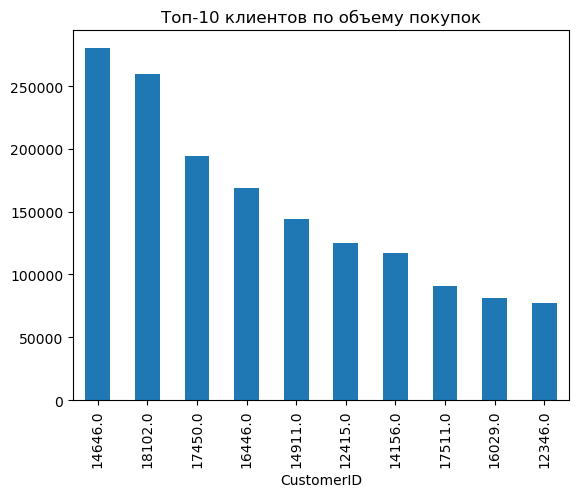

In [39]:
df['CustomerID'].nunique()
df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Топ-10 клиентов по объему покупок')
plt.show()

#### 8. Анализ по времени

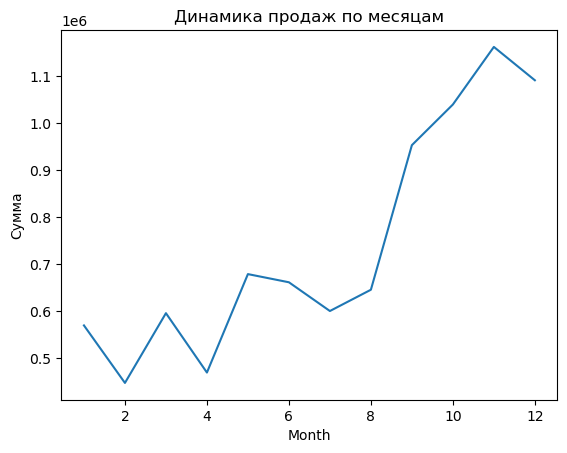

In [43]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.month
df.groupby('Month')['TotalPrice'].sum().plot(kind = 'line')
plt.title('Динамика продаж по месяцам')
plt.ylabel('Сумма')
plt.show()